In [11]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.gridspec as gridspec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
from scipy.ndimage import gaussian_filter


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
light = pd.read_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_oa.h5')

In [4]:
light

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,animal_mean_interp_ts_nose_y_cm,animal_median_interp_ts_nose_y_cm,animal_std_interp_ts_nose_y_cm,animal_mad_interp_ts_nose_y_cm,date_mean_interp_ts_nose_y_cm,date_median_interp_ts_nose_y_cm,date_std_interp_ts_nose_y_cm,date_mad_interp_ts_nose_y_cm,ts_inds,date_index
0,0,48054.835737,48059.792371,"[48054.850086, 48054.866291, 48054.883008, 480...","[[718, 719, 720, 721, 722, 723, 724, 725, 726,...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[646.5863647460938, 647.6791381835938, 647.953...","[256.8539123535156, 256.5686340332031, 256.810...","[655.6896362304688, 655.893798828125, 656.1171...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 6...",0.0
1,1,48059.792371,48066.055564,"[48059.801369, 48059.818099, 48059.834739, 480...","[1015, 1016, 1017, 1018, 1019, 1020, 1021, 102...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[100.70337677001953, 100.96659851074219, 100.9...","[229.06690979003906, 229.2141571044922, 229.14...","[97.77118682861328, 97.44432830810547, 97.2664...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 7...",0.0
2,2,48066.055564,48070.369088,"[48066.070515, 48066.087513, 48066.103731, 480...","[[1391, 1392, 1393, 1394, 1395, 1396, 1397, 13...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.5042114257812, 653.2907104492188, 653.849...","[249.86825561523438, 249.44972229003906, 249.3...","[653.6144409179688, 655.35498046875, 655.19451...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 6...",0.0
3,3,48070.369088,48076.550553,"[48070.37175, 48070.388352, 48070.40526, 48070...","[1649, 1650, 1651, 1652, 1653, 1654, 1655, 165...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[102.01713562011719, 102.3261489868164, 102.09...","[225.12435913085938, 225.2169189453125, 225.56...","[97.98050689697266, 98.4389877319336, 98.42494...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 9...",0.0
4,4,48076.550553,48079.610534,"[48076.557094, 48076.574464, 48076.590464, 480...","[[2020, 2021, 2022, 2023, 2024, 2025, 2026, 20...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[652.8433227539062, 653.4661254882812, 654.875...","[250.68643188476562, 250.68145751953125, 250.4...","[650.7364501953125, 652.0059814453125, 654.872...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 9...",0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13068,3485,54157.437376,54160.181888,"[54157.442931, 54157.460057, 54157.476339, 541...","[38364, 38365, 38366, 38367, 38368, 38369, 383...","[112.589599609375, 112.44923400878906, 111.815...","[274.62530517578125, 275.1161193847656, 276.02...","[131.68301391601562, 130.71107482910156, 129.9...","[267.4510498046875, 268.88592529296875, 269.51...","[121.9745101928711, 121.0912094116211, 121.124...",...,"[19.87070159369576, 19.87070159369576, 19.8707...","[21.420028620649106, 21.420028620649106, 21.42...","[2.802635025118742, 2.802635025118742, 2.80263...","[0.41952116492380753, 0.41952116492380753, 0.4...","[19.87070159369576, 19.87070159369576, 19.8707...","[21.420028620649106, 21.420028620649106, 21.42...","[2.802635025118742, 2.802635025118742, 2.80263...","[0.41952116492380753, 0.41952116492380753, 0.4...","[46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 5...",6.0
13069,3486,54160.181888,54163.549056,"[54160.194329, 54160.210636, 54160.227276, 541...","[[38529, 38530, 38531, 38532, 38533, 38534, 38...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan,

In [ ]:
J701RN = light[light.animal == 'J701RN']
df = J701RN
dictists = {key: [] for key in ['animal','date_index','obstacle_cluster',"trials",'fdist','start','odd']}
for date_id,date_id_df in df.groupby(['date_index']):
    for ani, ani_df in date_id_df.groupby(['animal']):
        for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
            for cluster,cluster_df in ani_df.groupby('obstacle_cluster'):
                for start,start_df in cluster_df.groupby('start'):
                    for odd,odd_df in start_df.groupby('odd'):
                        dictists['animal'].append(ani)
                        dictists['date_index'].append(odd_df.date_index.unique()[0])
                        dictists['trials'].append(len(odd_df))
                        dictists['obstacle_cluster'].append(odd_df.obstacle_cluster.unique()[0])
                        dictists['start'].append(odd_df.start.unique()[0])
                        dictists['odd'].append(odd_df.odd.unique()[0])
                        if len(odd_df) >=4:
                            sl, matx, maty = create_streamlines(odd_df,'ts_nose_x_cm','ts_nose_y_cm')
                            fdist_avg = []
                            for i,row in enumerate(tqdm(sl)):
                                fdist_list = []
                                for traj in sl: 
                                    avg_fdist = frdist(sl[i],traj)
                                    fdist_list.append(avg_fdist)
                                fdist_avg.append(np.nanmean(fdist_list))
                            dictists['fdist'].append(np.mean(fdist_avg))
                            
                        else:
                            dictists['fdist'].append(np.nan)


In [37]:
def compute_frenchet_distance(df):
    """returns df each row is the average frenchet distance of a cluster by direction, start, animal, and date_index"""
    dictists = {key: [] for key in ['animal','date_index','obstacle_cluster',"trials",'fdist','start','odd']}
    df = df
    for date_id,date_id_df in df.groupby(['date_index']):
        for ani, ani_df in date_id_df.groupby(['animal']):
            for cluster,cluster_df in tqdm(ani_df.groupby('obstacle_cluster')):
                for start,start_df in cluster_df.groupby('start'):
                    for odd,odd_df in start_df.groupby('odd'):
                        dictists['animal'].append(ani)
                        dictists['date_index'].append(odd_df.date_index.unique()[0])
                        dictists['trials'].append(len(odd_df))
                        dictists['obstacle_cluster'].append(odd_df.obstacle_cluster.unique()[0])
                        dictists['start'].append(odd_df.start.unique()[0])
                        dictists['odd'].append(odd_df.odd.unique()[0])
                        if len(odd_df) >=4:
                            sl, matx, maty = create_streamlines(odd_df,'ts_nose_x_cm','ts_nose_y_cm')
                            fdist_avg = []
                            for i,row in enumerate(sl):
                                fdist_list = []
                                for traj in sl: 
                                    avg_fdist = frdist(sl[i],traj)
                                    fdist_list.append(avg_fdist)
                                fdist_avg.append(np.nanmean(fdist_list))
                            dictists['fdist'].append(np.mean(fdist_avg))
                        else:
                            dictists['fdist'].append(np.nan)
    f_dist_df = pd.DataFrame.from_dict(dictists)
    return f_dist_df


In [38]:
light_fdist = compute_frenchet_distance(light)

100%|██████████| 6/6 [00:08<00:00,  1.44s/it]


In [2]:
light_fdist.to_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_fdist.h5','w')

NameError: name 'light_fdist' is not defined

In [5]:
light_fdist = pd.read_hdf(r'd:\obstacle_avoidance\metadata\SFN\data\light_fdist.h5')

In [3]:
light_fdist.fdist.isna().sum()

NameError: name 'light_fdist' is not defined

<AxesSubplot: >

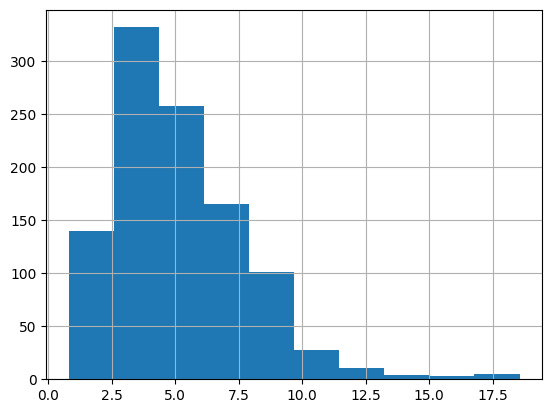

In [6]:
light_fdist.fdist.hist()

<AxesSubplot: >

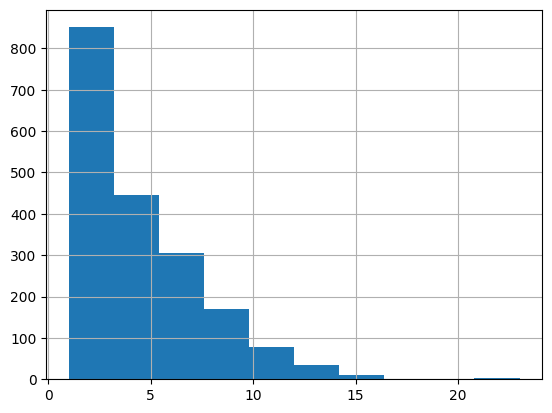

In [7]:
light_fdist.trials.hist()

In [2]:
light_fdist.to_hdf()

NameError: name 'light_fdist' is not defined

In [12]:

long,short,middle = create_df_by_type(light_fdist)

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

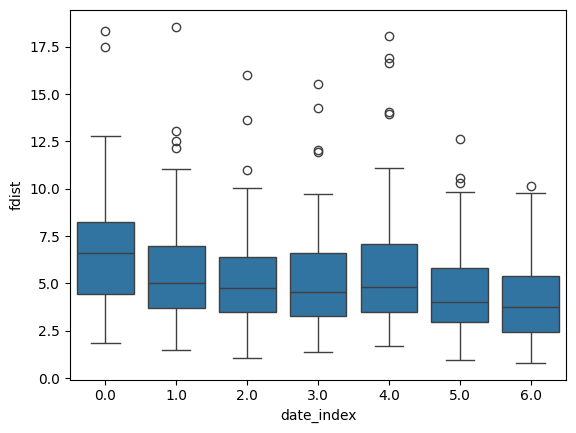

In [8]:
sns.boxplot(data=light_fdist,x='date_index',y='fdist')

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

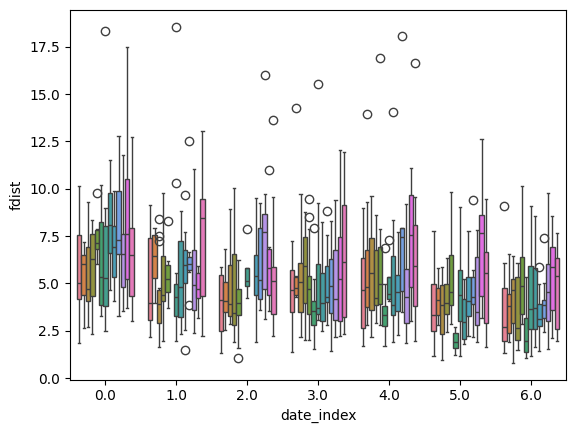

In [68]:
sns.boxplot(data=light_fdist,x='date_index',y='fdist',hue = 'animal',legend=False)

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

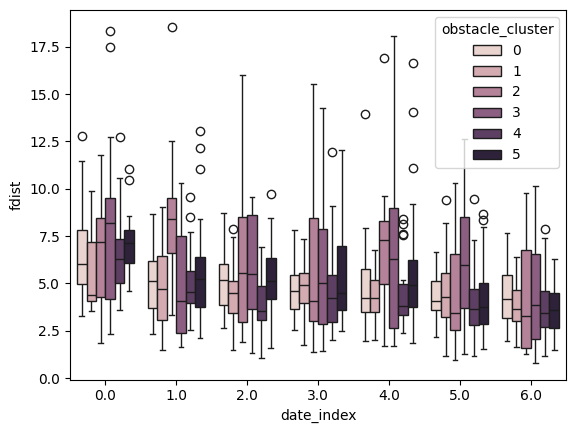

In [19]:
sns.boxplot(data=light_fdist,x='date_index',y='fdist',hue = 'obstacle_cluster')

<AxesSubplot: xlabel='date_index', ylabel='linearity'>

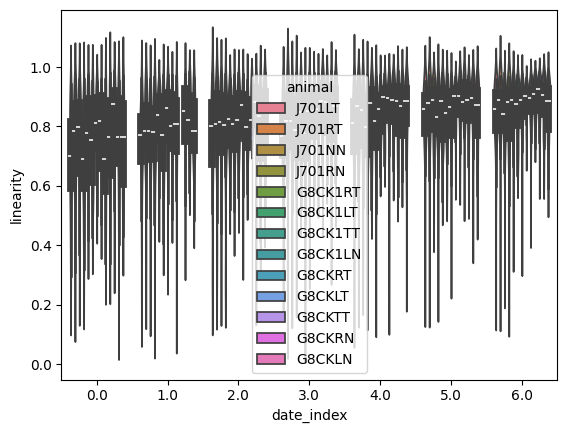

In [31]:
sns.violinplot(data=light,x='date_index',y='linearity',hue ='animal')

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

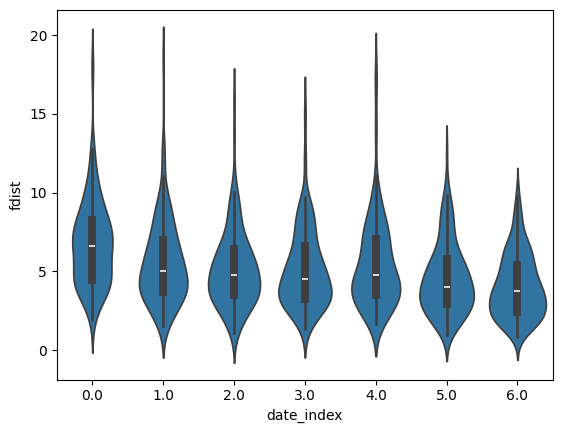

In [79]:
sns.violinplot(data=light_fdist,x='date_index',y='fdist')

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

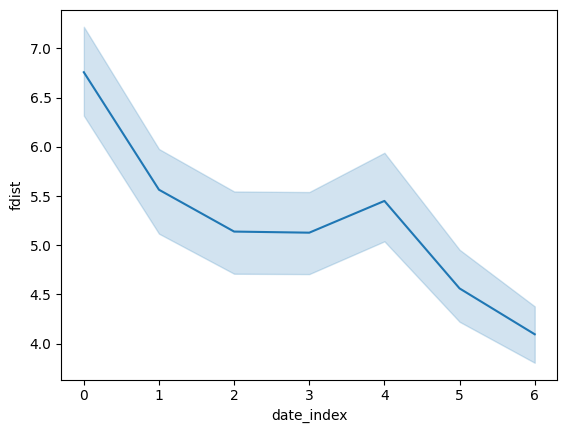

In [9]:
sns.lineplot(data=light_fdist,x='date_index',y='fdist',estimator='mean')

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

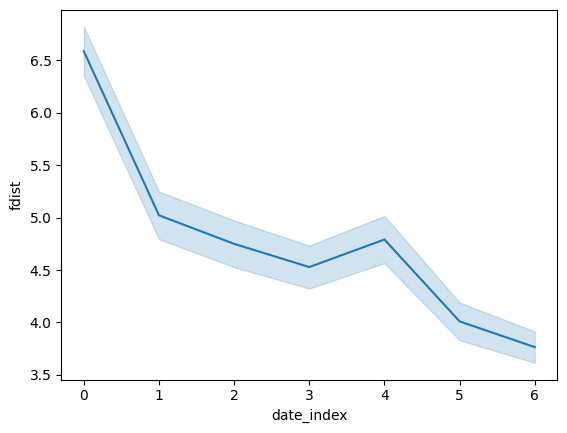

In [7]:
sns.lineplot(data=light_fdist,x='date_index',y='fdist',estimator='median',errorbar='se')

(0.0, 8.0)

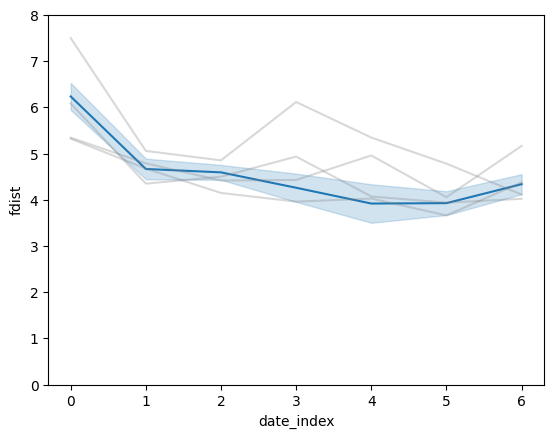

In [69]:
palette = sns.color_palette(['grey'], len(short['animal'].unique()))
sns.lineplot(data=short,x='date_index',y='fdist',estimator='median',errorbar='se')
sns.lineplot(data=short,x='date_index',y='fdist',hue ='obstacle_cluster',legend=False,palette = palette,ci =None,alpha = .3)
plt.ylim(0,8)

In [1]:
palette = sns.color_palette(['grey'], len(light_fdist['animal'].unique()))
sns.lineplot(data=light_fdist,x='date_index',y='fdist',estimator='median')
sns.lineplot(data=light_fdist,x='date_index',y='fdist',estimator='median',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)
plt.ylim(0,8)


NameError: name 'sns' is not defined

In [12]:
palette = sns.color_palette(['grey'], len(light['animal'].unique()))
sns.lineplot(data=light,x='date_index',y='linearity',estimator='median',errorbar='se')
sns.lineplot(data=light,x='date_index',y='linearity',hue ='animal',estimator='median',legend=False,palette = palette,ci =None,alpha = .3)

NameError: name 'light' is not defined

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

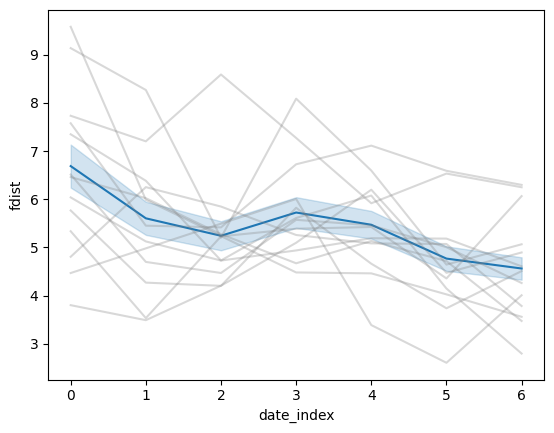

In [53]:
palette = sns.color_palette(['grey'], len(long['animal'].unique()))
sns.lineplot(data=long,x='date_index',y='fdist',estimator='mean',errorbar='se')
sns.lineplot(data=long,x='date_index',y='fdist',hue ='animal',legend=False,palette = palette,ci =None,alpha = .3)

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

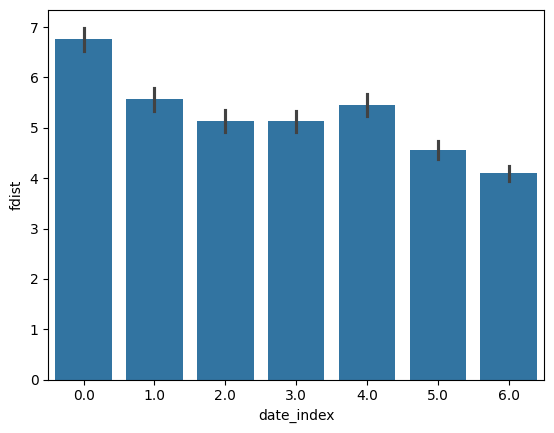

In [9]:
sns.barplot(data=light_fdist,x='date_index',y='fdist',estimator='mean',errorbar='se')

4


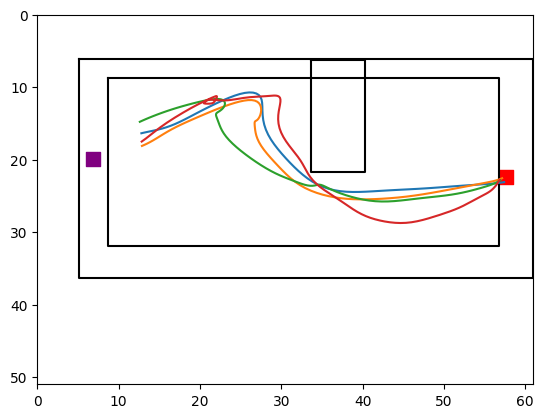

In [30]:
J701RN = light[(light.date_index==6.0) &(light.obstacle_cluster==1)&(light.odd=='left')&(light.start=='top')&(light.animal=='J701RT') ]
fig,ax = plt.subplots()
plot_arena(J701RN,ax,outer=True)
plot_orginal_obstacle(J701RN,ax,0)
print(len(J701RN))
for ind, row in J701RN.iterrows():
    x = gaussian_filter(row.ts_nose_x_cm.astype(float),3)
    y = gaussian_filter(row.ts_nose_y_cm.astype(float),3)
    ax.plot(x.astype(float),y.astype(float))

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

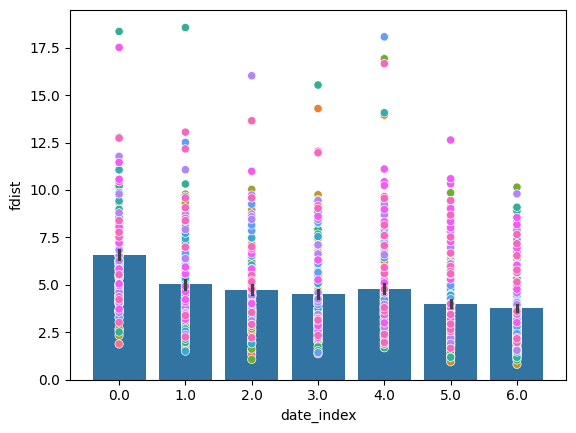

In [27]:
sns.barplot(data=light_fdist,x='date_index',y='fdist',estimator='median',errorbar='se')
sns.scatterplot(data = light_fdist,x='date_index',y='fdist',hue='animal' ,legend=False)

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

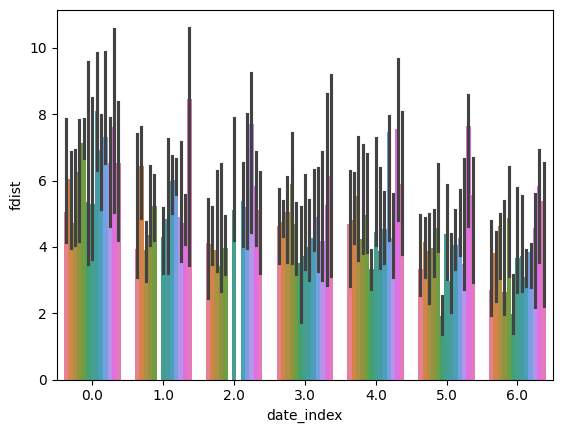

In [35]:
sns.barplot(data=light_fdist,x='date_index',y='fdist',estimator='median',hue ='animal',legend=False)

<AxesSubplot: xlabel='date_index', ylabel='fdist'>

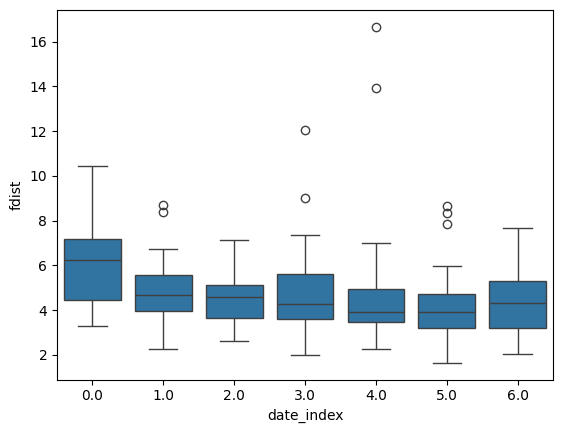

In [16]:
sns.boxplot(data=short,x='date_index',y='fdist')